## 국민연금 데이터 분석

In [42]:
# [분석 목표]
# 국민연금공단 국민연금 가입 사업장 내역 데이터를 분석하여

# ▶월별 탈퇴 기업
# ▶시도별 탈퇴한 기업
# ▶상하반기 탈퇴한 기업

# '회사명' 을 입력을 하면,
#  ▶회사명을 기준으로 간단한 정보출력
#  ▶회사에 근무하신 직원들의 평균적인 월급여 추정액, 연봉추정액, 가입자 수 출력
#  ▶동종 업종 대비 평균 연봉의 차이
#  ▶동종 업계는 얼마 정도 받는지 출력.

# import

In [43]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# pandas, 글꼴 설정

In [44]:
pd.set_option('display.float_format',  '{:.1f}'.format)
# ↑실수값을 소숫점 이하 1자리까지 표시
# 6.170000e+06 -> 6170000.0 로 표시

pd.set_option('display.max_columns', None)
# DataFrame을 출력할 때 보여줄 수 있는 최대 컬럼 수를 설정
#  None을 주면 모든 컬럼을 숨김 없이 출력

In [45]:
# colab 한글 fonts-nanum 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [46]:
# colab 한글 fonts-nanum 설치
import matplotlib.font_manager as fm

NanumBarunGothic_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 리눅스 폰트 경로
fm.fontManager.addfont(NanumBarunGothic_path) # 폰트메니저에 폰트를 직접적으로 주입

plt.rc('font', family='NanumBarunGothic')

# ■ 데이터 준비

## 데이터 다운로드
- 데이터셋: **국민연금공단_국민연금 가입 사업장 내역**
  - 출처: 공공 데이터 포털(data.go.kr)
  - https://www.data.go.kr/data/15083277/fileData.do

  - 위 페이지 들어가서 CSV 파일 다운로드 합니다.  (다운로드 할때, 언제 마지막으로 업데이트 된 데이터인지 팝업 뜹니다)
  - 형태: 파일데이터 (csv)
    - ex: "국민연금공단_국민연금 가입 사업장 내역_20251124.csv"

## 데이터 로딩

In [47]:
# 구글 드라이브 마운트
base_path = r'/content/drive/MyDrive/KoreaIT (코리아it)/260113 💚AI MCP 에이전트 S1/[MCP_Agent]/dataset(MCP2601)'

In [48]:
FILE_NAME = r'국민연금 가입 사업장 내역_20251124.csv'
df = pd.read_csv(os.path.join(base_path, FILE_NAME), encoding='cp949')
df.head(3)

/tmp/ipython-input-500/2179760997.py:2: DtypeWarning: Columns (4,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(base_path, FILE_NAME), encoding='cp949')


,자료생성년월,사업장명,사업자등록번호,사업장가입상태코드 1 등록 2 탈퇴,우편번호,사업장지번상세주소,사업장도로명상세주소,고객법정동주소코드,고객행정동주소코드,법정동주소광역시도코드,법정동주소광역시시군구코드,법정동주소광역시시군구읍면동코드,사업장형태구분코드 1 법인 2 개인,사업장업종코드,사업장업종코드명,적용일자,재등록일자,탈퇴일자,가입자수,당월고지금액,신규취득자수,상실가입자수
0,2025-10,대신정보통신(주),133850,1,08500,서울특별시 금천구 가산동,서울특별시 금천구 가산디지털2로,1154510100,1154551000,11,545,101,1,722000,응용 소프트웨어 개발 및 공급업,1988-01-01,NaN,NaN,630,218882720,5,15
1,2025-10,(주)장성,214815,1,13511,경기도 성남시 분당구 야탑동,경기도 성남시 분당구 판교로,4113510700,4113561000,41,135,107,1,172902,그 외 기타 분류 안된 섬유제품 제조업,1988-01-01,NaN,NaN,3,1228320,0,0
2,2025-10,서울명지초등학교,111820,1,03656,서울특별시 서대문구 홍은동,서울특별시 서대문구 명지2길,1141011800,1141068000,11,410,118,1,999999,BIZ_NO미존재사업장,1988-01-01,NaN,NaN,31,6608900,0,0


In [49]:
df.shape

(590501, 22)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590501 entries, 0 to 590500
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   자료생성년월               590501 non-null  object
 1   사업장명                 590501 non-null  object
 2   사업자등록번호              590501 non-null  int64 
 3   사업장가입상태코드 1 등록 2 탈퇴  590501 non-null  int64 
 4   우편번호                 590501 non-null  object
 5   사업장지번상세주소            590501 non-null  object
 6   사업장도로명상세주소           570085 non-null  object
 7   고객법정동주소코드            590501 non-null  int64 
 8   고객행정동주소코드            590501 non-null  object
 9   법정동주소광역시도코드          590501 non-null  int64 
 10  법정동주소광역시시군구코드        590501 non-null  int64 
 11  법정동주소광역시시군구읍면동코드     590501 non-null  int64 
 12  사업장형태구분코드 1 법인 2 개인  590501 non-null  int64 
 13  사업장업종코드              590501 non-null  int64 
 14  사업장업종코드명             589769 non-null  object
 15  적용일자                 590500 non-nu

In [51]:
df.columns

Index(['자료생성년월', '사업장명', '사업자등록번호', '사업장가입상태코드 1 등록 2 탈퇴', '우편번호', '사업장지번상세주소',
       '사업장도로명상세주소', '고객법정동주소코드', '고객행정동주소코드', '법정동주소광역시도코드', '법정동주소광역시시군구코드',
       '법정동주소광역시시군구읍면동코드', '사업장형태구분코드 1 법인 2 개인', '사업장업종코드', '사업장업종코드명',
       '적용일자', '재등록일자', '탈퇴일자', '가입자수', '당월고지금액', '신규취득자수', '상실가입자수'],
      dtype='object')


## 데이터셋 소개




- 사업장 컬럼별 상세설명 (`2025.12 현재`)

  - 자료생성년월 → 자격마감일(사유발생일이 속하는 달의 다음달 15일)까지 신고분 반영
  - 가입자 수 → 가입자 수(고지인원 수 포함)
  - 당월고지금액 → 국민연금법 시행령 제5조에 의거 기준소득월액 상한액 적용으로 실제소득과 고지금액은 상이할 수 있음

    - ■상한액 2021.7. ~ 2022.6. 5,240,000원
    - ■상한액 2022.7. ~ 2023.6. 5,530,000원
    - ■상한액 2023.7. ~ 2024.6. 5,900,000원
    - ■상한액 2024.7. ~ 2025.6. 6,170,000원
    - ■상한액 2025.7. ~ 2026.6. 6,370,000원

  - 신규취득자수 → 납부재개 포함 : ※ 전달 고지대상자와 비교하므로 실제 취득자와 상이할 수 있음 (초일취득 (고지)초일이 아닌경우 (당월 미고지되며 다음달 취득자수에 반영)
  - 상실가입자수 → 납부예외 포함 : ※ 전달 고지대상자와 비교하므로 실제 퇴사자와 상이할 수 있음 (초일이 아닌 상실자는 다음달 상실자수에 반영)

※ 국민연금법 제6조, 8조, 동법 시행령 제18조에 의거 60세 도달하거나 퇴직연금수급자, 조기노령연금 수급권을 취득한 자는 가입대상에서 제외되며, 18세미만, 기초수급자는 본인희망에 의해 제외될 수 있음

# ■ 전처리

## 컬럼명 변경하기
원본 DataFrame을 다음의 컬럼명으로 변경하여 다루어보겠습니다
- 다루기 용이한 컬럼명으로 변경
- 분석목표에 불필요한 컬럼은 삭제
- **삭제**로 표기된 컬럼은 삭제 합니다.



|                          변경 전 | 변경 후                 |
| -------------------------------: | ----------------------- |
|                     자료생성년월 | **삭제**                |
|                         사업장명 | 사업장명                |
|                   사업자등록번호 | 사업자등록번호          |
| 사업장가입상태코드 1 등록 2 탈퇴 | 가입상태                |
|                         우편번호 | **삭제**            |
|               사업장지번상세주소 | **삭제**                |
|             사업장도로명상세주소 | 주소                    |
|               고객법정동주소코드 | **삭제**                |
|               고객행정동주소코드 | **삭제**                |
|           법정동주소광역시도코드 | 시도코드                |
|       법정동주소광역시시군구코드 | 시군구코드              |
| 법정동주소광역시시군구읍면동코드 | 읍면동코드              |
| 사업장형태구분코드 1 법인 2 개인 | **삭제**                |
|                   사업장업종코드 | 업종코드                |
|                 사업장업종코드명 | 업종코드명              |
|                         적용일자 | **삭제**                |
|                       재등록일자 | **삭제**                |
|                         탈퇴일자 | 탈퇴일자                |
|                         가입자수 | 가입자수                |
|                     당월고지금액 | 금액                    |
|                     신규취득자수 | 신규                    |
|                     상실가입자수 | 상실                    |



In [52]:
# 원본 컬럼명 확인
df.columns

Index(['자료생성년월', '사업장명', '사업자등록번호', '사업장가입상태코드 1 등록 2 탈퇴', '우편번호', '사업장지번상세주소',
       '사업장도로명상세주소', '고객법정동주소코드', '고객행정동주소코드', '법정동주소광역시도코드', '법정동주소광역시시군구코드',
       '법정동주소광역시시군구읍면동코드', '사업장형태구분코드 1 법인 2 개인', '사업장업종코드', '사업장업종코드명',
       '적용일자', '재등록일자', '탈퇴일자', '가입자수', '당월고지금액', '신규취득자수', '상실가입자수'],
      dtype='object')

In [53]:
# 원본 shape
df.shape

(590501, 22)

In [54]:
# 컬럼명 변경하기
df.columns = [
    '자료생성년월', '사업장명', '사업자등록번호', '가입상태', '우편번호',
    '사업장지번상세주소', '주소', '고객법정동주소코드', '고객행정동주소코드',
    '시도코드', '시군구코드', '읍면동코드',
    '사업장형태구분코드 1 법인 2 개인', '업종코드', '업종코드명',
    '적용일자', '재등록일자', '탈퇴일자',
    '가입자수', '금액', '신규', '상실'
]

# 8개 컬럼 삭제하기
df.drop([
    '자료생성년월', '우편번호', '사업장지번상세주소', '고객법정동주소코드',
    '고객행정동주소코드', '사업장형태구분코드 1 법인 2 개인', '적용일자', '재등록일자'
], axis=1, inplace=True)

print(df.shape)

df.head()

(590501, 14)


,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
0,대신정보통신(주),133850,1,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,NaN,630,218882720,5,15
1,(주)장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
2,서울명지초등학교,111820,1,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,NaN,31,6608900,0,0
3,세종실업(주),114810,1,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,NaN,16,4647780,1,0
4,(주)경농,214810,1,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,NaN,381,158749940,9,9


## NaN 처리하기

In [55]:
df.columns

Index(['사업장명', '사업자등록번호', '가입상태', '주소', '시도코드', '시군구코드', '읍면동코드', '업종코드',
       '업종코드명', '탈퇴일자', '가입자수', '금액', '신규', '상실'],
      dtype='object')

In [56]:
# 특정 컬럼에 대해서만 dropna 하기
# 분석에 꼭 필요한 '사업장명', '사업자등록번호', '시도'  컬럼에서 값이 없는 '행' 삭제
df.dropna(subset=['사업장명', '사업자등록번호', '시도코드'], inplace=True)

df.shape
# ↑ 삭제된 내역이 있을 수도 있고 없을수도 있다.  (그때 그때 원본 데이터 상태 마다 다르다.)

(590501, 14)

## 사업장명 클린징

`사업장명` 컬럼에 대하여 다음 조건의 클린징을 적용해보자

1. `(주)` 와 같은 문자열은 ()안에 문자를 포함하여 일괄 제거합니다.
2. `[주식회사]`와 같이 [] 안에 문자열 포함하여 일괄 제거합니다.
3. `숫자`, `한글`, `영어`를 제외한 특수문자는 공백으로 대체 합니다.
4. 만약 공백이 1개 이상이 들어간 경우는 1개로 대체합니다.

`사업장명`에서 (주) 를 제거해보자.

In [57]:
df['사업장명']


,사업장명
0,대신정보통신(주)
1,(주)장성
2,서울명지초등학교
3,세종실업(주)
4,(주)경농
...,...
590496,누리이앤씨(주)/일용/2열연 바히터 레일 및 ORP 댐퍼 교체 공사
590497,(주)대양/일용/춘천 청평사 회전문 전통단청 보수공사
590498,일원엔지니어링(주)/일용/서울도시철도7호선청라국제도시연장1공구건설공사중청라7호선1공...
590499,에이씨아이건설（주）/일용/(주)HIVAC 제2공장 신축공사 중 미장공사


In [58]:
df['사업장명'].str

# StringMethods객체
# 문자열(string) 데이터에 대해 벡터화된 문자열 연산을 제공하는 접근자(accessor)
# 즉, 파이썬의 문자열 메서드(upper, split, contains 등)를 Series 전체에 한 번에 적용할 수 있게 해줍니다.

In [59]:
# 메소드 contains() 는 정규표현식을 매개변수로 갇는다
df['사업장명'].str.contains(r'\(주\)')


,사업장명
0,True
1,True
2,False
3,True
4,True
...,...
590496,True
590497,True
590498,True
590499,True


In [60]:
df.head()

,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
0,대신정보통신(주),133850,1,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,NaN,630,218882720,5,15
1,(주)장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
2,서울명지초등학교,111820,1,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,NaN,31,6608900,0,0
3,세종실업(주),114810,1,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,NaN,16,4647780,1,0
4,(주)경농,214810,1,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,NaN,381,158749940,9,9


In [61]:
df.loc[df['사업장명'].str.contains(r'\(주\)')].head()


,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
0,대신정보통신(주),133850,1,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,NaN,630,218882720,5,15
1,(주)장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
3,세종실업(주),114810,1,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,NaN,16,4647780,1,0
4,(주)경농,214810,1,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,NaN,381,158749940,9,9
5,(주)니프코코리아,211814,1,충청남도 아산시 둔포면 아산밸리남로,44,200,360,252901,포장용 플라스틱 성형용기 제조업,NaN,612,339711840,1,3


In [62]:
# 우성기전(주)에서 (주) 라는 글자는 제거하는 경우

pattern1 = r'(\([^)]+\))'
re.sub(pattern1, '', '우성기전(주)')


'우성기전'

사업장명에서 [] 특수문자를 포함하는 경우 []안쪽 글자까지 제거하는 경우

In [63]:
# 사업장명 에 "["  가 포함 있는 것들 확인
df.loc[df['사업장명'].str.contains(r'\[')].head()


,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
54373,에스티테크[주],606817,1,부산광역시 사하구 감천항로419번길,26,380,107,291502,기타 물품 취급장비 제조업,NaN,10,3953680,0,0
77919,[주)한빛관리 은행대우 3차1단지/ 생활지원센타],212813,1,경기도 시흥시 은행로,41,390,106,702003,비주거용 부동산 관리업,NaN,4,1139480,0,0
95096,JS가든 [청담점],211856,1,서울특별시 강남구 도산대로,11,680,108,999999,BIZ_NO미존재사업장,NaN,20,6181920,2,1
101863,주식회사 디큐산업[Design Quality Industry],105878,1,서울특별시 은평구 증산로,11,380,109,999999,BIZ_NO미존재사업장,NaN,11,2491600,0,0
103903,[구립]가정보금자리어린이집,137803,1,NaN,28,260,108,999999,BIZ_NO미존재사업장,NaN,18,3704600,0,0


(예시) `에스티테크[주]`에서 [주]를 삭제 하고 싶은 경우

In [64]:
pattern2 = r'(\[[^)]+\])'
re.sub(pattern2, '', '에스티테크[ 주 ]')


'에스티테크'

In [65]:
# 사업장명에 특수문자  가령. '/' 이 있는 경우
df.loc[df['사업장명'].str.contains(r'\/')].head()


,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
966,재우교통/주,205812,1,서울특별시 마포구 가양대로,11,440,127,602201,택시 운송업,NaN,3,838780,0,0
2299,(주)한영파트너스FH/월드컵현대아파트,138810,1,서울특별시 서대문구 수색로,11,410,119,702003,비주거용 부동산 관리업,NaN,3,1021120,0,0
10173,사)강원도지체장애인협회고성군지회/장애인종합상담실/편의,227826,1,강원특별자치도 고성군 간성읍 간성로30번길,51,820,250,999999,BIZ_NO미존재사업장,NaN,3,949760,0,0
12975,민현건설(주)/본사,507810,1,대전광역시 서구 대덕대로,30,170,113,452102,유리 및 창호 공사업,NaN,3,389700,0,0
15074,원광건설(주)/본사,506814,1,경상북도 영양군 영양읍 군청길,47,760,250,0,해당없음,NaN,7,303000,0,0


그 밖의 모든 특수문자는 제거합니다. (제거한 특수문자에는 공백을 삽입합니다)

In [66]:
pattern3 = '[^A-Za-z0-9가-힣]'
# 알파벳, 숫자,한글 제외한 특수문자 제거
result = re.sub(pattern3, ' ', '*^%$^의료법인%해정^&*****%!@의료재단/더/   좋은/병원')

# 공백 여러개는 한개로 바꾸기
result = re.sub(' +', ' ', result)
result



' 의료법인 해정 의료재단 더 좋은 병원'

In [67]:
# 검증코드 (변경전)
# ※ 위 확인 내용에서 index 값 가져옵니다.
df.loc[[1, 95096, 2299]]



,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
1,(주)장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
95096,JS가든 [청담점],211856,1,서울특별시 강남구 도산대로,11,680,108,999999,BIZ_NO미존재사업장,NaN,20,6181920,2,1
2299,(주)한영파트너스FH/월드컵현대아파트,138810,1,서울특별시 서대문구 수색로,11,410,119,702003,비주거용 부동산 관리업,NaN,3,1021120,0,0


In [68]:
def preprocessing(x):
    x = re.sub(pattern1, '', x)   # () 제거
    x = re.sub(pattern2, '', x)   # [] 제거
    x = re.sub(pattern3, ' ', x)  # 그 밖의 특수문자 제거
    x = re.sub(' +', ' ', x)    # 공백 여러개도 한개로 축소
    return x.strip()

df['사업장명'] = df['사업장명'].apply(preprocessing)


In [69]:
# 검증코드 (변경후)
df.loc[[1, 95096, 2299]]


,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
1,장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
95096,JS가든,211856,1,서울특별시 강남구 도산대로,11,680,108,999999,BIZ_NO미존재사업장,NaN,20,6181920,2,1
2299,한영파트너스FH 월드컵현대아파트,138810,1,서울특별시 서대문구 수색로,11,410,119,702003,비주거용 부동산 관리업,NaN,3,1021120,0,0


# ■ 분석1

## 파생변수, mask 준비

In [70]:
# 분석연도
year = 2025


In [71]:
# 파생변수 추가
# '연도' 와 '월'
df['탈퇴일자_연도'] = pd.to_datetime(df['탈퇴일자']).dt.year
df['탈퇴일자_월'] = pd.to_datetime(df['탈퇴일자']).dt.month

# '시도'
df['시도'] = df['주소'].str.split(' ').str[0]

df.head()

,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실,탈퇴일자_연도,탈퇴일자_월,시도
0,대신정보통신,133850,1,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,NaN,630,218882720,5,15,NaN,NaN,서울특별시
1,장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0,NaN,NaN,경기도
2,서울명지초등학교,111820,1,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,NaN,31,6608900,0,0,NaN,NaN,서울특별시
3,세종실업,114810,1,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,NaN,16,4647780,1,0,NaN,NaN,서울특별시
4,경농,214810,1,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,NaN,381,158749940,9,9,NaN,NaN,서울특별시


In [72]:
# 자주 사용할 mask 준비
가입사업장 = (df['가입상태'] == 1)
탈퇴사업장 = (df['가입상태'] == 2)

분석연도 = (df['탈퇴일자_연도'] == year)
분석연도탈퇴사업장 = 탈퇴사업장 & 분석연도


## 월별 탈퇴 기업수
특정연도에 탈퇴한 기업의 월별 탈퇴 수를 bar그래프로 출력합니다.

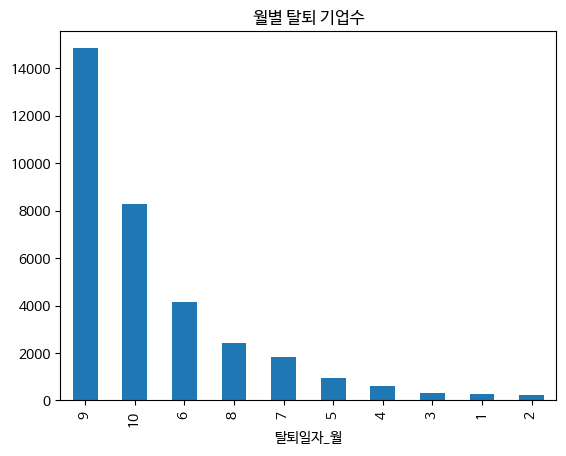

In [73]:
df.loc[분석연도탈퇴사업장, '탈퇴일자_월']\
  .astype('int')\
  .value_counts()\
  .plot(kind='bar')

plt.title('월별 탈퇴 기업수')
plt.show()


## 시도별 탈퇴한 기업수
특정연도에 탈퇴한 기업을 대상으로 시도별 탈퇴한 기업의 숫자를 bar 그래프로 출력하세요

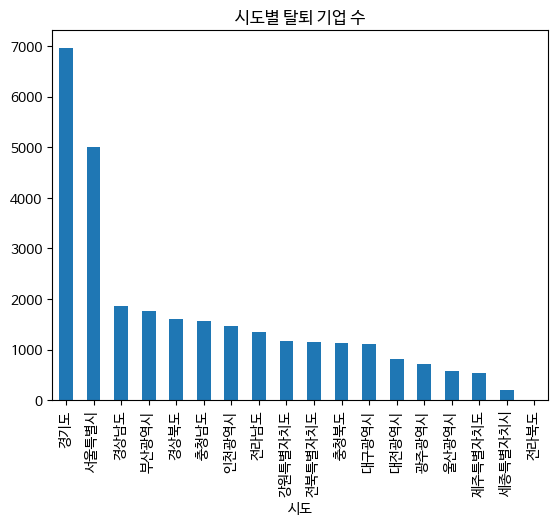

In [74]:
df.loc[분석연도탈퇴사업장, '시도']\
  .value_counts()\
  .plot(kind='bar')

plt.title('시도별 탈퇴 기업 수')
plt.show()


## 상하반기 기업탈퇴수 비교
탈퇴한 기업을 대상으로 연도별 상반기 / 하반기별 기업의 탈퇴 수를 비교합니다.
- 비교대상은 start_year년 ~ end_year년을 기준으로 산정합니다.

In [75]:
# 분석 시작연도 ~ 종료연도
# ※데이터 공식 페이지의 당월 고지 금액 참조

start_year = 2021  # 🔹TODO
end_year = 2025  # 🔹TODO

```python
numpy.where(condition, x, y)
```
조건에 따라 값을 선택하거나, 조건을 만족하는 위치(인덱스)를 찾을 때 사용하는 함수

In [76]:
# where() 함수 예
arr = np.array([1, 2, 3, 4, 5])
result = np.where(arr > 3, 100, 0)
print(result)

[  0   0   0 100 100]


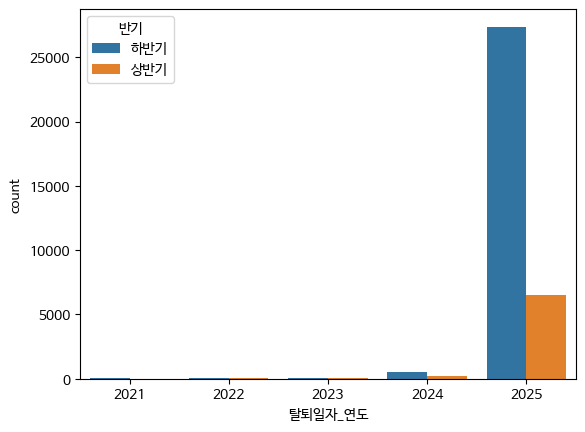

In [77]:
# 탈퇴일자가 start_year ~ end_year 사이인 탈퇴 사업장 boolean mask
cond1 = 탈퇴사업장 & (df['탈퇴일자_연도'] >= start_year) & (df['탈퇴일자_연도'] <= end_year)

tmp = df.loc[cond1].copy()
tmp['반기'] = np.where(tmp['탈퇴일자_월'] <= 6, '상반기', '하반기')
tmp['탈퇴일자_연도'] = tmp['탈퇴일자_연도'].astype('int')

sns.countplot(data=tmp, x='탈퇴일자_연도', hue='반기')
plt.show()


# ■ 분석2

## 탈퇴 기업 삭제
- `가입상태`가 2 (탈퇴)인 데이터는 삭제 합니다.
- `가입상태`, `탈퇴일자` 컬럼을 제거하세요.

In [78]:
#  이 다음 분석을 위해 df 를 다시 리셋하겠습니다
df.columns
df.drop(['탈퇴일자_연도', '탈퇴일자_월', '시도'], axis=1, inplace=True)

df.head()

,사업장명,사업자등록번호,가입상태,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,탈퇴일자,가입자수,금액,신규,상실
0,대신정보통신,133850,1,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,NaN,630,218882720,5,15
1,장성,214815,1,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,NaN,3,1228320,0,0
2,서울명지초등학교,111820,1,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,NaN,31,6608900,0,0
3,세종실업,114810,1,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,NaN,16,4647780,1,0
4,경농,214810,1,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,NaN,381,158749940,9,9


In [79]:
df = df.loc[가입사업장].drop(['가입상태', '탈퇴일자'], axis=1).reset_index(drop=True)
print(df.shape)
df.head()

(555445, 12)


,사업장명,사업자등록번호,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,가입자수,금액,신규,상실
0,대신정보통신,133850,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,630,218882720,5,15
1,장성,214815,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,3,1228320,0,0
2,서울명지초등학교,111820,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,31,6608900,0,0
3,세종실업,114810,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,16,4647780,1,0
4,경농,214810,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,381,158749940,9,9


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555445 entries, 0 to 555444
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   사업장명     555445 non-null  object
 1   사업자등록번호  555445 non-null  int64 
 2   주소       540065 non-null  object
 3   시도코드     555445 non-null  int64 
 4   시군구코드    555445 non-null  int64 
 5   읍면동코드    555445 non-null  int64 
 6   업종코드     555445 non-null  int64 
 7   업종코드명    554723 non-null  object
 8   가입자수     555445 non-null  int64 
 9   금액       555445 non-null  int64 
 10  신규       555445 non-null  int64 
 11  상실       555445 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 50.9+ MB


In [81]:
df.columns

Index(['사업장명', '사업자등록번호', '주소', '시도코드', '시군구코드', '읍면동코드', '업종코드', '업종코드명',
       '가입자수', '금액', '신규', '상실'],
      dtype='object')

## 핵심 데이터 column 추출

- 수도권(서울, 경기도) 소재의 기업을 대상으로 합니다 (시도코드 11, 41).
- `가입자수`를 기준으로 내림차순 정렬하여 bar 그래프를 출력합니다.
- 출력되는 사업장명은 상위 20개만 출력합니다.

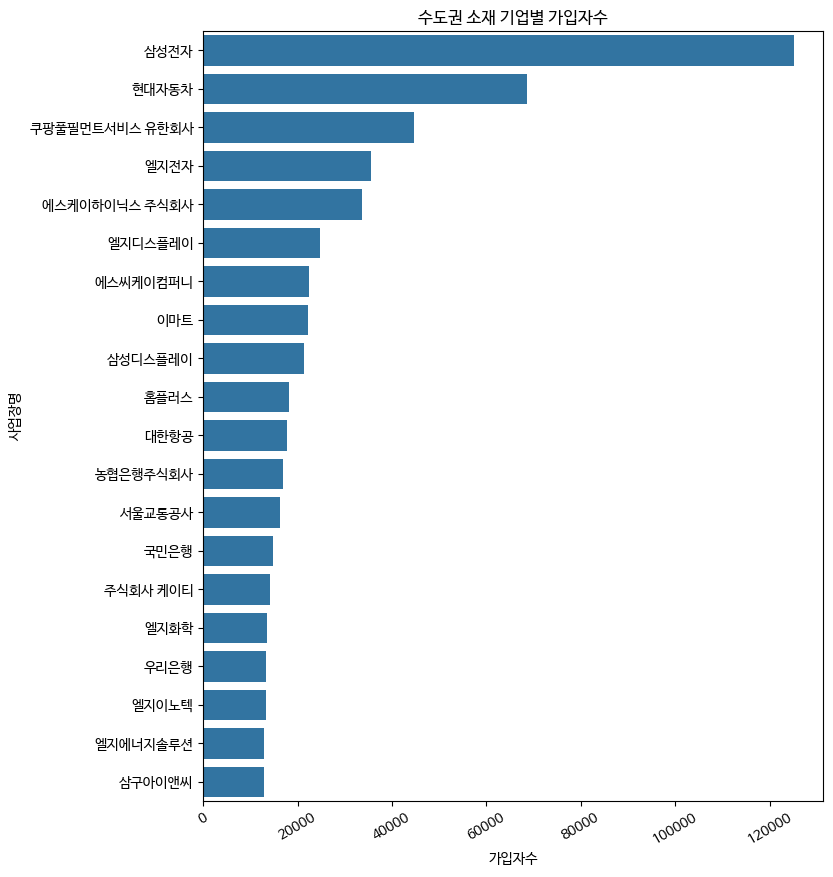

In [82]:
tmp = df.loc[df['시도코드'].isin([11, 41]), ['사업장명', '가입자수']]\
      .sort_values('가입자수', ascending=False)\
      .head(20)\
      .reset_index()

plt.figure(figsize=(8, 10))
sns.barplot(y='사업장명', x='가입자수', data=tmp)
plt.xticks(rotation=30)
plt.title('수도권 소재 기업별 가입자수')
plt.show()






## 국민연금 납부액으로 기업별 평균 연봉 추정

국민연금 보험률은 9%입니다. 쉽게 이야기 하면 급여(신고소득월액)의 9%를 국민연금으로 내는 것입니다.

하지만 이를 절반으로 나누어 **4.5%는 회사가, 나머지 절반은 개인이 부담하는 구조**입니다. 회사는 급여 외에 추가로 금액을 부담합니다.

국민연금 보험료는 **소득 상한선과 하한선이 설정되어 있어 소득 전체가 아닌 일부 소득에만 부과**됩니다.

이를 역산하면 신고소득월액의 계산이 가능합니다. 하지만 **상한선과 하한선이 설정되어 있어 실제보다 과소계산**될 수 있습니다
<br><br>
[수식]

- 인당금액 = 금액 / 가입자수
- 월급여추정 = 인당금액 / 9% * 100%
- 연간급여추정 = 임직원 평균 월급 * 12개월
<br><br>
- 금액을 가입자수로 나눈 금액을 산출하여 `인당금액`을 먼저 산출합니다.
- `월급여추정`은 `인당금액` / 9% * 100% 한 값입니다.
- `월급여추정`을 x12한 값을 `연간급여추정`에 대입합니다.
- `가입자수` 기준 1000명을 초과하는 기업(중견기업)을 필터링 합니다.
- 출력시 `사업장명`, `가입자수`, `월급여추정`, `연간급여추정` 컬럼만 출력합니다.
- `연간급여추정`와 `가입자수`를 기준으로 내림차순하여 상위 10개 기업을 출력합니다.

In [83]:
df.head()

,사업장명,사업자등록번호,주소,시도코드,시군구코드,읍면동코드,업종코드,업종코드명,가입자수,금액,신규,상실
0,대신정보통신,133850,서울특별시 금천구 가산디지털2로,11,545,101,722000,응용 소프트웨어 개발 및 공급업,630,218882720,5,15
1,장성,214815,경기도 성남시 분당구 판교로,41,135,107,172902,그 외 기타 분류 안된 섬유제품 제조업,3,1228320,0,0
2,서울명지초등학교,111820,서울특별시 서대문구 명지2길,11,410,118,999999,BIZ_NO미존재사업장,31,6608900,0,0
3,세종실업,114810,서울특별시 강남구 개포로140길,11,680,114,452111,시설물 유지관리 공사업,16,4647780,1,0
4,경농,214810,서울특별시 서초구 효령로77길,11,650,108,242102,화학 살균ㆍ살충제 및 농업용 약제 제조업,381,158749940,9,9


### 파생변수 추가

In [87]:
# 파생변수 추가
# '인당금액', '월급여추청', '연간급여추정'

df['인당금액'] = df['금액'] / df['가입자수']
df['월급여추정'] = df['인당금액'] / 9 * 100
df['연간급여추정'] = df['월급여추정'] * 12

# 확인. 가입자수 1000명 이상
cond = (df['가입자수'] > 1000)

df.sort_values(['연간급여추정', '가입자수'], ascending=False)\
  .loc[cond, ['사업장명', '가입자수', '월급여추정', '연간급여추정']]\
  .head(10)



,사업장명,가입자수,월급여추정,연간급여추정
2987,기아 영업본부,2013,6370000.0,76440000.0
47664,현대제철포항1공장,1334,6351199.4,76214392.8
384396,부산항만산업협회 화물고정업,1090,6347262.4,76167148.6
285142,한국지엠주식회사,7777,6343068.8,76116825.9
94540,삼성디스플레이,21361,6334876.4,76018516.9
280397,기아 정비본부,1156,6320235.7,75842828.1
321326,현대제철주식회사,1521,6313422.6,75761071.2
405490,삼성물산건설부문 정규직,4645,6306194.5,75674334.3
47125,현대트랜시스주식회사,4079,6303488.3,75641859.3
278861,주식회사 케이티,14200,6302117.2,75625406.2


## 업종별 가입자수 순유입 산정

- `순유입`은 `신규` - `상실` 로 정의합니다.
- `업종코드명`별 순유입의 합산을 구한 후 상위 20개 `업종코드명`에 대하여 bar 그래프로 출력합니다.
- `순유입` 기준으로 내림차순 정렬합니다.

In [89]:
df['순유입'] = df['신규'] - df['상실']

df.groupby('업종코드명')['순유입'].sum().sort_values(ascending=False).head(20)



,순유입
업종코드명,
배관 및 냉ㆍ난방 공사업,10568
비주거용 건물 임대업(점포 자기땅),9658
콘크리트 및 철근 공사업,7421
미장 타일 및 방수 공사업,6648
유리 및 창호 공사업,4628
해당없음,3950
도배 실내 장식 및 내장 목공사업,3471
기타 토목 시설물 건설업,2867
토공사업,2126


## 사업장명 검색

- 사업장명을 검색한 후 결과를 return하는 함수를 완성합니다.
- 함수명은 `find_company` 입니다.
- 매개변수 contains=:
          True인 경우: string의 `contains`를 사용하여 포함하는 모든 회사를 찾습니다.
          False인 경우: 정확히 일치하는 사업장명만 찾습니다.
          
- `def find_company(company_name, contains)`
- `['사업장명', '월급여추정', '연간급여추정', '업종코드']` 정보를 보여주는 DataFrame을 return 합니다.

In [ ]:
df.head()

In [91]:
# contains=True : company_name 값이 포함만되어도 선택
# contains=False : 정확히 company_name 이 사업장만 선택
def find_company(company_name, contains):
    if contains:
        return df.loc[
            df['사업장명'].str.contains(company_name),
            ['사업장명', '월급여추정', '연간급여추정', '업종코드', '가입자수']
        ].sort_values('가입자수', ascending=False)
    else:
        return df.loc[
            df['사업장명'] == company_name,  # 정확히 일치하는 것만 선택
            ['사업장명', '월급여추정', '연간급여추정', '업종코드', '가입자수']
        ].sort_values('가입자수', ascending=False)

# 검증코드
find_company('에스케이텔레콤', False)

,사업장명,월급여추정,연간급여추정,업종코드,가입자수
278892,에스케이텔레콤,6054528.6,72654343.5,642001,5401


In [ ]:
# 검증코드
find_company('에스케이텔레콤', False)

## 업종코드 동일한 회사 비교

- 사업장명을 입력하면 사업장명과 정확히 일치하는 회사를 찾습니다. (find_company 함수 사용)
- 함수명은 `compare_company` 입니다.
- 매개변수명은 `company_name` 으로 지정하세요
- `def compare_company(company_name)`

기능
- find_company로 부터 return 된 DataFrame의 업종코드와 동일한 회사를 모두 찾습니다.
- 동일한 회사의 `월급여추정`, `연간급여추정`에 대한 ['mean', 'count', 'min', 'max']를 산출합니다.

return 되는 DataFrame은 다음과 같이 구성합니다.
- index: `월급여추정` -> `업종_월급여추정`, `연간급여추정` -> `업종_연간급여추정`으로 변경합니다.
- 컬럼은 평균, 개수, 최소, 최대로 컬럼명을 변경 후 맨 끝열에는 찾은 회사명 컬럼을 추가하고, `월급여추정`, `연간급여추정` 데이터를 기입합니다.


In [92]:
# 회사 기본 정보를 리턴하는 함수.
def company_info(company_name):
    company = find_company(company_name, True)
    return df.loc[company.iloc[0].name]   # 검색된 company 중 가장 가입자수가 많은 회사 1개 선택

# 동작확인
info = company_info('에스케이텔레콤')
info

,278892
사업장명,에스케이텔레콤
사업자등록번호,104813
주소,서울특별시 중구 을지로
시도코드,11
시군구코드,140
읍면동코드,105
업종코드,642001
업종코드명,무선 및 위성 통신업
가입자수,5401
금액,2943045820


In [101]:
# 주어진 사업장과 업종코드 동일한 회사 비교
def compare_company(company_name):
    company = find_company(company_name, True)
    code = company['업종코드'].iloc[0]
    df1 = df.loc[df['업종코드'] == code, ['월급여추정', '연간급여추정']].agg(['mean', 'count', 'min', 'max'])
    df1.columns = ['업종_월급여추정', '업종_연간급여추정']
    df1 = df1.T
    df1.columns = ['평균', '개수', '최소', '최대']
    df1.loc['업종_월급여추정', company_name] = company['월급여추정'].values[0]
    df1.loc['업종_연간급여추정', company_name] = company['연간급여추정'].values[0]

    return df1


# 검증코드
result = compare_company('삼성전자')
result

,평균,개수,최소,최대,삼성전자
업종_월급여추정,3434798.5,431.0,568897.6,6339333.3,6263228.6
업종_연간급여추정,41217582.1,431.0,6826771.2,76072000.0,75158743.0


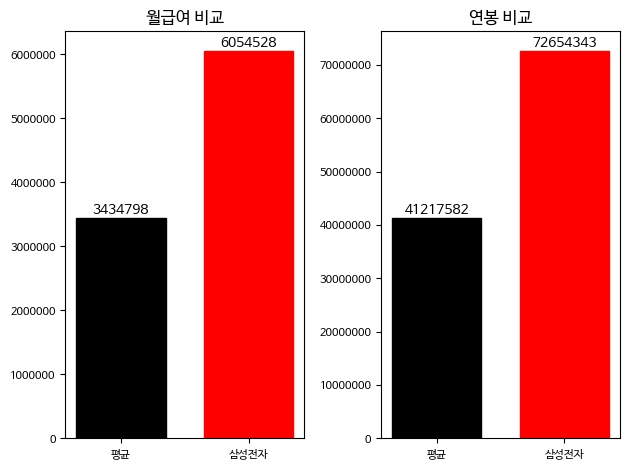

In [102]:
fig, ax = plt.subplots(1, 2)

p1 = ax[0].bar(x=['평균', '삼성전자'], height=(result.iloc[0, 0], info['월급여추정']), width=0.7)
ax[0].bar_label(p1, fmt='%d')
p1[0].set_color('black')
p1[1].set_color('red')
ax[0].ticklabel_format(style='plain', axis='y')
ax[0].set_title('월급여 비교')

p2 = ax[1].bar(x=['평균', '삼성전자'], height=(result.iloc[1, 0], info['연간급여추정']), width=0.7)
p2[0].set_color('black')
p2[1].set_color('red')
ax[1].bar_label(p2, fmt='%d')
ax[1].ticklabel_format(style='plain', axis='y')
ax[1].set_title('연봉 비교')

ax[0].tick_params(axis='both', which='major', labelsize=8, rotation=0)
ax[0].tick_params(axis='both', which='minor', labelsize=6)
ax[1].tick_params(axis='both', which='major', labelsize=8)
ax[1].tick_params(axis='both', which='minor', labelsize=6)

plt.tight_layout()  # 플롯의 레이아웃을 자동으로 조정해, 서브플롯이나 레이블, 타이틀 등이 겹치지 않도록 여백을 최적화

In [ ]:
# 🔹TODO
